# Tox21 Missing Label Imputation — SAGE→GIN→SAGE GNN

This notebook trains one SAGE→GIN→SAGE model **per Tox21 task** on the rows that
have a known label, then uses those models to predict the missing labels.
The result is a fully-filled `tox21_imputed.csv` with no NaN values.

**Important caveat**: imputed labels are model predictions, not experimental measurements.
Label this clearly in any paper — call them "GNN-imputed" labels, not ground truth.

Run on **Colab T4 GPU**.


## 1 · Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, sys

DRIVE_ROOT = '/content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX'
DATA_CSV   = f'{DRIVE_ROOT}/tox21_dataset.csv'
OUT_CSV    = f'{DRIVE_ROOT}/tox21_imputed.csv'
CKPT_DIR   = f'{DRIVE_ROOT}/imputation_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)

print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


## 2 · Install dependencies

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch_geometric', 'rdkit'], check=True)
print('Done.')


Done.


## 3 · Imports

In [3]:
import warnings, random, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp

from rdkit import Chem
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 4 · Load utils.py from Drive

In [4]:
from utils import (
    get_atom_features,
    get_bond_features,
    create_pytorch_geometric_graph_data_list_from_smiles_and_labels as smiles_to_graphs,
    save_ckp,
    load_ckp,
    optimizer_to,
)
print('utils.py loaded.')


utils.py loaded.


## 5 · Configuration

In [5]:
# ── Model (same architecture as experiment notebook) ─────────────────────
LAYER_TYPES = ['sage', 'gin', 'sage']
HIDDEN_DIM  = 224
DROPOUT     = 0.0006
LR          = 0.0004

# ── Training ──────────────────────────────────────────────────────────────
MAX_EPOCHS           = 300
EVAL_EVERY           = 10
PATIENCE             = 30
NUM_GRAPHS_PER_BATCH = 64
SEED                 = 42

# ── Tox21 tasks ──────────────────────────────────────────────────────────
TOX21_TASKS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Will train one model per task: {TOX21_TASKS}')
print(f'Architecture: {LAYER_TYPES}  hidden={HIDDEN_DIM}  dropout={DROPOUT}  lr={LR}')


Will train one model per task: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Architecture: ['sage', 'gin', 'sage']  hidden=224  dropout=0.0006  lr=0.0004


## 6 · Load full dataset (keep NaN rows)

In [6]:
df_full = pd.read_csv(DATA_CSV)
print(f'Full dataset shape: {df_full.shape}')
print('\nMissing values per task:')
print(df_full[TOX21_TASKS].isna().sum().to_string())

# Pre-filter: keep only rows where SMILES is valid
valid_mask = df_full['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)
df_full    = df_full[valid_mask].reset_index(drop=True)
print(f'\nAfter removing invalid SMILES: {len(df_full)} molecules')

ALL_SMILES = list(df_full['smiles'])


Full dataset shape: (7831, 14)

Missing values per task:
NR-AR             566
NR-AR-LBD        1073
NR-AhR           1282
NR-Aromatase     2010
NR-ER            1638
NR-ER-LBD         876
NR-PPAR-gamma    1381
SR-ARE           1999
SR-ATAD5          759
SR-HSE           1364
SR-MMP           2021
SR-p53           1057


[15:10:05] WARNING: not removing hydrogen atom without neighbors
[15:10:05] Explicit valence for atom # 8 Al, 6, is greater than permitted
[15:10:05] Explicit valence for atom # 3 Al, 6, is greater than permitted
[15:10:05] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:10:06] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:10:06] Explicit valence for atom # 9 Al, 6, is greater than permitted
[15:10:06] Explicit valence for atom # 5 Al, 6, is greater than permitted
[15:10:06] Explicit valence for atom # 16 Al, 6, is greater than permitted
[15:10:06] Explicit valence for atom # 20 Al, 6, is greater than permitted



After removing invalid SMILES: 7823 molecules


## 7 · GNN model

In [7]:
class GNN(torch.nn.Module):
    def __init__(self, layer_types, hidden_dim, dropout):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        in_dim = 79
        for lt in layer_types:
            if lt == 'gcn':
                self.convs.append(GCNConv(in_dim, hidden_dim))
            elif lt == 'gat':
                self.convs.append(GATConv(in_dim, hidden_dim))
            elif lt == 'gin':
                mlp = nn.Sequential(
                    nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
                self.convs.append(GINConv(mlp, eps=0.00005, train_eps=True))
            elif lt == 'sage':
                self.convs.append(SAGEConv(in_dim, hidden_dim))
            in_dim = hidden_dim
        self.drop = nn.Dropout(p=dropout)
        self.out  = Linear(hidden_dim * 2, 1)

    def forward(self, x, edge_index, batch_index):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = torch.tanh(x)
        x = self.drop(x)
        x = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)
        return self.out(x)


def evaluate_auc(model, loader):
    model.eval()
    yt, ys = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            probs = torch.sigmoid(
                model(batch.x.float(), batch.edge_index, batch.batch).squeeze())
            yt.append(batch.y.cpu().numpy())
            ys.append(probs.cpu().numpy())
    yt = np.concatenate(yt)
    ys = np.concatenate(ys)
    if len(np.unique(yt)) < 2:
        return float('nan')
    return roc_auc_score(yt, ys)


def predict_proba(model, smiles_list, batch_size=128):
    """Return sigmoid probabilities for a list of SMILES (no labels needed)."""
    # Build graphs with dummy label 0
    data = smiles_to_graphs(smiles_list, [0.0] * len(smiles_list))
    loader = DataLoader(data, batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            p = torch.sigmoid(
                model(batch.x.float(), batch.edge_index, batch.batch).squeeze())
            # squeeze() on a single-element batch returns a scalar — handle it
            if p.dim() == 0:
                p = p.unsqueeze(0)
            probs.extend(p.cpu().numpy().tolist())
    return np.array(probs)


print('GNN and helpers defined.')


GNN and helpers defined.


## 8 · Train one model per task & impute missing labels

For each task:
1. Split molecules into **known** (label available) and **unknown** (NaN)
2. Train SAGE→GIN→SAGE on the known subset
3. Predict probabilities for the unknown subset
4. Threshold at 0.5 → binary imputed label
5. Save model checkpoint and record AUC on a held-out validation split


In [ ]:
# Will store imputed values here before writing back to df_full
imputed_df = df_full.copy()

task_results = []   # AUC per task

for task in TOX21_TASKS:
    print(f'\n{"="*55}')
    print(f'Task: {task}')

    # ── Known vs unknown rows ──────────────────────────────────────────────
    known_mask   = df_full[task].notna()
    unknown_mask = df_full[task].isna()

    known_smiles   = list(df_full.loc[known_mask,   'smiles'])
    known_labels   = list(df_full.loc[known_mask,   task].astype(float))
    unknown_smiles = list(df_full.loc[unknown_mask, 'smiles'])

    print(f'  Known: {len(known_smiles)}  |  Missing to impute: {len(unknown_smiles)}')

    if len(known_smiles) < 100:
        print(f'  Skipping (too few known labels to train reliably)')
        continue

    # ── Compute pos_weight for this task ──────────────────────────────────
    n_pos = sum(known_labels)
    n_neg = len(known_labels) - n_pos
    pw    = max(1.0, n_neg / (n_pos + 1e-8))
    print(f'  Pos: {int(n_pos)}  Neg: {int(n_neg)}  pos_weight: {pw:.2f}')

    # ── Build graph list for known molecules ──────────────────────────────
    data_known = smiles_to_graphs(known_smiles, known_labels)

    # 80/20 train/val split (no scaffold split here — imputation, not evaluation)
    n_known  = len(data_known)
    n_train  = int(0.8 * n_known)
    indices  = list(range(n_known))
    random.shuffle(indices)
    train_data = [data_known[i] for i in indices[:n_train]]
    val_data   = [data_known[i] for i in indices[n_train:]]

    train_loader = DataLoader(train_data, batch_size=NUM_GRAPHS_PER_BATCH,
                              shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_data,   batch_size=NUM_GRAPHS_PER_BATCH,
                              shuffle=False, drop_last=False)

    # ── Model, optimiser, loss ────────────────────────────────────────────
    torch.manual_seed(SEED)
    model     = GNN(LAYER_TYPES, HIDDEN_DIM, DROPOUT).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = torch.nn.BCEWithLogitsLoss(
        pos_weight=torch.FloatTensor([pw]).to(device))

    # ── Training loop with early stopping ────────────────────────────────
    best_val_auc  = 0.0
    patience_ctr  = 0
    best_state    = None

    for epoch in range(MAX_EPOCHS):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch.x.float(), batch.edge_index, batch.batch).squeeze()
            criterion(pred, batch.y).backward()
            optimizer.step()

        if (epoch + 1) % EVAL_EVERY == 0:
            val_auc = evaluate_auc(model, val_loader)
            if not np.isnan(val_auc) and val_auc > best_val_auc:
                best_val_auc = val_auc
                patience_ctr = 0
                best_state = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Early stop at epoch {epoch+1} | val AUC {best_val_auc:.4f}')
                break

    print(f'  Best val AUC: {best_val_auc:.4f}')
    task_results.append({'task': task, 'val_auc': best_val_auc,
                         'n_known': len(known_smiles), 'n_imputed': len(unknown_smiles)})

    # ── Save checkpoint ───────────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
    ckpt_path = os.path.join(CKPT_DIR, f'{task.replace("-","_")}_imputer.pt')
    torch.save({'state_dict': model.state_dict(), 'task': task,
                'val_auc': best_val_auc}, ckpt_path)

    # ── Impute missing labels ─────────────────────────────────────────────
    if len(unknown_smiles) > 0:
        probs = predict_proba(model, unknown_smiles)
        imputed_labels = (probs >= 0.5).astype(float)
        imputed_df.loc[unknown_mask, task] = imputed_labels
        print(f'  Imputed {len(unknown_smiles)} labels '
              f'(predicted positive: {imputed_labels.sum():.0f})')

print('\n' + '='*55)
print('All tasks complete.')



Task: NR-AR
  Known: 7258  |  Missing to impute: 565
  Pos: 308  Neg: 6950  pos_weight: 22.56


[15:10:06] WARNING: not removing hydrogen atom without neighbors


  Best val AUC: 0.8091
  Imputed 565 labels (predicted positive: 82)

Task: NR-AR-LBD
  Known: 6751  |  Missing to impute: 1072
  Pos: 237  Neg: 6514  pos_weight: 27.49


[15:14:40] WARNING: not removing hydrogen atom without neighbors


  Best val AUC: 0.8911
  Imputed 1072 labels (predicted positive: 56)

Task: NR-AhR
  Known: 6542  |  Missing to impute: 1281
  Pos: 768  Neg: 5774  pos_weight: 7.52


...

  Best val AUC: 0.8690
  Imputed 1363 labels (predicted positive: 480)

Task: SR-MMP
  Known: 5804  |  Missing to impute: 2019
  Pos: 918  Neg: 4886  pos_weight: 5.32


[15:48:24] WARNING: not removing hydrogen atom without neighbors


  Best val AUC: 0.9065
  Imputed 2019 labels (predicted positive: 455)

Task: SR-p53
  Known: 6767  |  Missing to impute: 1056
  Pos: 423  Neg: 6344  pos_weight: 15.00


[15:51:49] WARNING: not removing hydrogen atom without neighbors


  Best val AUC: 0.8680
  Imputed 1056 labels (predicted positive: 251)

All tasks complete.


## 9 · Save imputed dataset & summary

In [ ]:
# Verify no NaN left in task columns
remaining_nan = imputed_df[TOX21_TASKS].isna().sum().sum()
print(f'Remaining NaN values in task columns: {remaining_nan}')

imputed_df.to_csv(OUT_CSV, index=False)
print(f'Imputed dataset saved to {OUT_CSV}')
print(f'Shape: {imputed_df.shape}')

# ── Summary table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(task_results)
print('\nImputation model performance (validation AUC):')
print(results_df.to_string(index=False))

avg_auc = results_df['val_auc'].mean()
print(f'\nMean val AUC across tasks: {avg_auc:.4f}')
print()
print('NOTE: Lower AUC tasks produced less reliable imputed labels.')
print('Consider excluding tasks with val AUC < 0.65 from downstream training.')


Remaining NaN values in task columns: 0
Imputed dataset saved to /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX/tox21_imputed.csv
Shape: (7823, 14)

Imputation model performance (validation AUC):
         task  val_auc  n_known  n_imputed
        NR-AR 0.809113     7258        565
    NR-AR-LBD 0.891131     6751       1072
       NR-AhR 0.912564     6542       1281
 NR-Aromatase 0.829223     5815       2008
        NR-ER 0.713292     6186       1637
    NR-ER-LBD 0.787456     6948        875
NR-PPAR-gamma 0.873404     6443       1380
       SR-ARE 0.850113     5825       1998
     SR-ATAD5 0.880066     7065        758
       SR-HSE 0.868992     6460       1363
       SR-MMP 0.906476     5804       2019
       SR-p53 0.868009     6767       1056

Mean val AUC across tasks: 0.8492

NOTE: Lower AUC tasks produced less reliable imputed labels.
Consider excluding tasks with val AUC < 0.65 from downstream training.


## 10 · Visualise imputation quality & label distributions

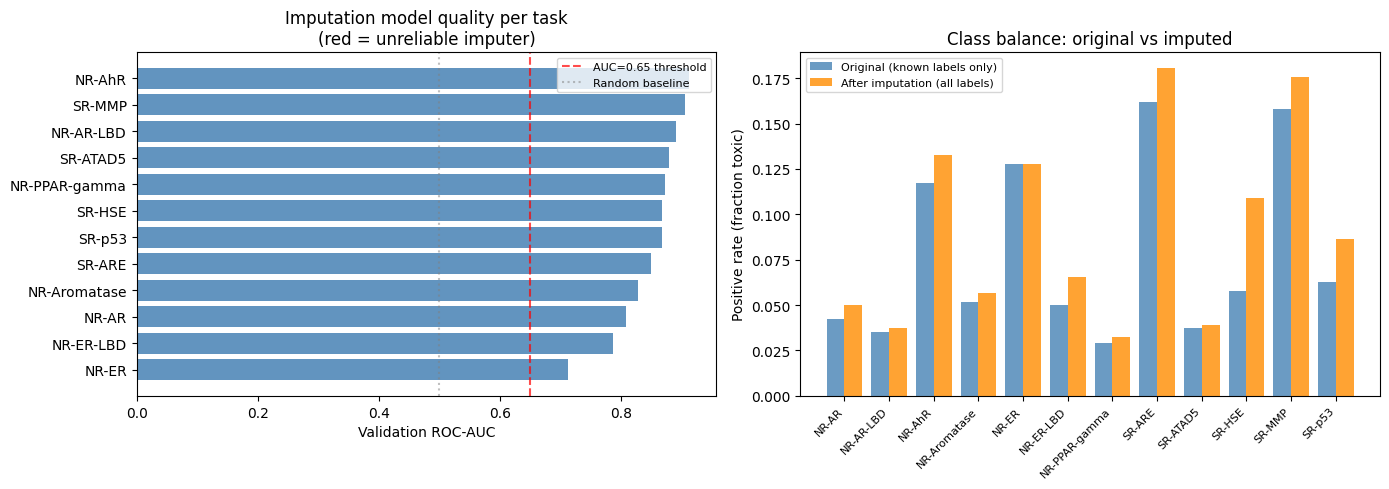

Plot saved to /content/drive/MyDrive/AUA/Thesis/code/HybridGNN/TOX/results_tox21/imputation_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: val AUC per task ─────────────────────────────────────────────────
tasks_sorted = results_df.sort_values('val_auc', ascending=True)
colors = ['tomato' if v < 0.65 else 'steelblue' for v in tasks_sorted['val_auc']]
axes[0].barh(tasks_sorted['task'], tasks_sorted['val_auc'], color=colors, alpha=0.85)
axes[0].axvline(0.65, color='red', linestyle='--', alpha=0.7, label='AUC=0.65 threshold')
axes[0].axvline(0.5,  color='grey', linestyle=':', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('Validation ROC-AUC')
axes[0].set_title('Imputation model quality per task\n(red = unreliable imputer)')
axes[0].legend(fontsize=8)

# ── Right: positive rate before/after imputation ───────────────────────────
original_pos_rate  = df_full[TOX21_TASKS].mean()
imputed_pos_rate   = imputed_df[TOX21_TASKS].mean()

x = range(len(TOX21_TASKS))
axes[1].bar([i - 0.2 for i in x], original_pos_rate.values, width=0.4,
            label='Original (known labels only)', color='steelblue', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], imputed_pos_rate.values, width=0.4,
            label='After imputation (all labels)', color='darkorange', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Positive rate (fraction toxic)')
axes[1].set_title('Class balance: original vs imputed')
axes[1].legend(fontsize=8)

plt.tight_layout()
plot_path = f'{DRIVE_ROOT}/results_tox21/imputation_summary.png'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved to {plot_path}')


## 11 · How to use `tox21_imputed.csv` for multi-task training

In your experiment notebook, instead of:
```python
df_task = df[['smiles', 'SR-ARE']].dropna()
```
do:
```python
df_imputed = pd.read_csv('tox21_imputed.csv')
# All 12 tasks, no NaN — train multi-task or per-task without dropping rows
```

**Best practice for your paper:**
- Train two versions: one on original labels only, one on imputed labels
- Report both AUC scores — the improvement (or lack thereof) from imputation is itself a finding
- Flag imputed labels in the paper: *"Missing labels were imputed using a SAGE→GIN→SAGE model
  trained on the known subset of each task (mean val AUC = X.XX)"*
